# Time Series and Geospatial Analysis

Please indicate your name and student id clearly in the submission title and in the file. 



## Question 1

Please use the same data set as in Assignment 1 for the following plot. 

Visualize the time series: Regular Unleaded Gasoline price in "London" from 2000 to 2022. Smooth the time series using simple moving average with windowsize=5.

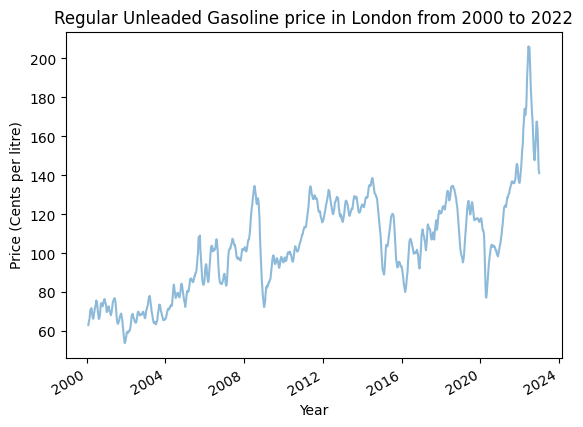

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fueltypesall1991-2023.csv')

#converting date into date object
df['Date'] = pd.to_datetime(df['Date'])
#df.info()
#df['Date'].max()

#not accurate but a way
#filter = (df['Date'] >= '2000') & (df['Date'] <= '2022')
#df.loc[filter]

df.set_index('Date', inplace = True)
series = df.loc[df['Fuel Type'] == 'Regular Unleaded Gasoline']['2000': '2022']['London']
series_smooth = series.rolling(window = 5).mean()


#plot the graph
series_smooth.plot(kind='line', alpha = 0.5)
plt.title("Regular Unleaded Gasoline price in London from 2000 to 2022")
plt.xlabel("Year")
plt.ylabel("Price (Cents per litre)")
plt.show()

## Question 2

The following data set includes the volcanos in the world. 
https://github.com/plotly/datasets/blob/master/volcano_db.csv

Please plot a map with three countries: Canada, US and Mexico. Show the exact locations (latitude and longitude) of the volcanos on this map.


In [107]:
import pandas as pd
import geopandas


volcano = pd.read_csv('volcano_db.csv', encoding = "ISO-8859-1")
world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))

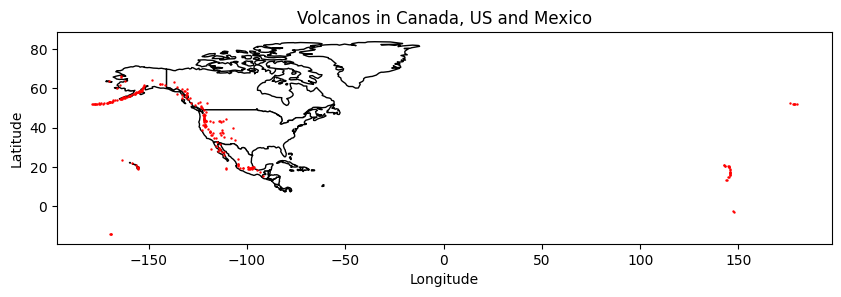

In [123]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt

volcano = pd.read_csv('volcano_db.csv', encoding = "ISO-8859-1")

#choose all the countries
df = volcano[(volcano['Country'] == 'Canada') |
             (volcano['Country'] == 'Mexico') |
             (volcano['Country'] == 'United States')]

#geodata object
df_geodata = geopandas.GeoDataFrame(df, geometry = geopandas.points_from_xy(df['Longitude'], df['Latitude']))

#world type
world = geopandas.read_file(geopandas.datasets.get_path('naturalearth_lowres'))

#choose from world type
map = world[world.continent == 'North America']

#graph the mapp
fig, ax = plt.subplots(figsize=(10, 8))
map.plot(ax = ax, color='white', edgecolor='black')
df_geodata.plot(ax = ax, color='red', markersize = 0.5)
plt.title("Volcanos in Canada, US and Mexico")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

